# Module 2: Epidemic Modeling Template

## Team Members:
Isabel Vikesland

Mohamed Elfaki

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



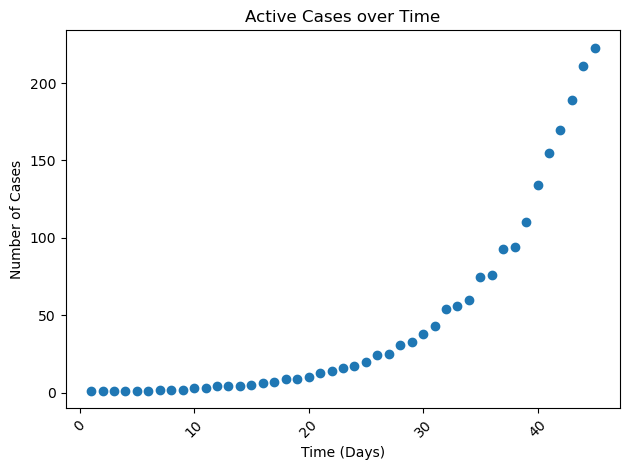

In [11]:
#import the patients class and the matplotlib library for plotting
from patients import Patients
import matplotlib.pyplot as plt
#find the location of the csv file and instantiate the patients class with that location
location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv"
patients = Patients.instantiate_from_csv(location)
#define a function to plot the data from the patients class
def plot_data_release_1(patients):
    dates = [patient.day for patient in patients]
    cases = [patient.number_of_cases for patient in patients]
    #format the scatter plot with the dates on the x-axis and the number of cases on the y-axis
    plt.scatter(dates, cases)
    plt.xlabel('Time (Days)')
    plt.ylabel('Number of Cases')
    plt.title('Active Cases over Time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

###I used ClaudeAI to help explain why my patients import statement was not working, it was because my patients.py file was in a different subfolder than my jupyter notebook

plot_data_release_1(patients) 

### What do you notice about the initial infections?
The initial infections occur at a barely imperceptible rate, almost one infection occuring at a time.


### How could we measure how quickly its spreading?
We can measure how quickly the disease is spreading by calculating R0. One way to estimate this is by identifying the doubling time from the curve, seeing how many days it takes for number of cases to double, and working backwards to infer the reproduction number.


### What information about the virus would be helpful in determining the shape of the outbreak curve?
Knowing the latency and infectious period would be helpful as they influence how long the virus circulates, directly affecting the R0. Knowing the transmissibility would help predict how steeply the curve grows. Additionally, knowing the level of pre-existing immunity in the population would help estimate when the curve might peak and begin to flatten, as immunity reduces the pool of susceptible individuals


### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

Best exponential window: day 22 to 35 (length 14)
Fit on log(I): R^2 = 0.9942
Growth rate r: 0.1281 per day
Doubling time: 5.41 days
Assumed infectious period D: 5.0 days
Estimated R0 = 1 + r*D = 1.64


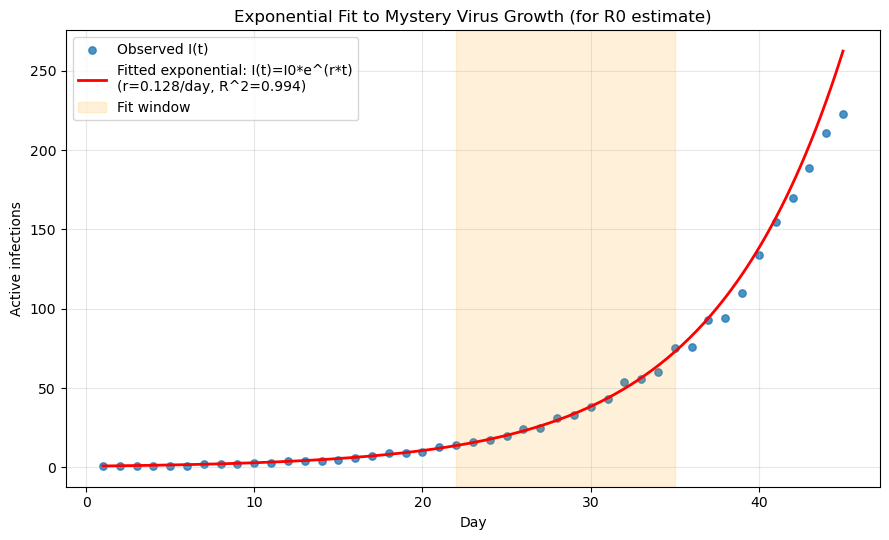

In [ ]:
#R0_mystery_virus
#import statements
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from patients import Patients

# control settings for virus window search and R0 estimation
infectious_period_days = 5.0
min_window = 7
max_window = 14

# data from data release #1
location = r"/Users/isabelvikesland/Documents/UVA2/BME 2315 - Comp.BME/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv"
patients = Patients.instantiate_from_csv(location)

# data for fitting: days and active cases in empty lists
days = []
cases = []
for p in patients:
    days.append(p.day)
    cases.append(p.number_of_cases if p.number_of_cases > 0 else 1e-6)

# fit log(I) = r * t + log(I0) for each window and find the best fit based on R^2
def fit_exp_window(tw, Iw):
    """
    Fit log(I) = r * t + log(I0).
    Returns r, I0, r2 (R-squared on log-scale).
    """
    logI = [np.log(val) for val in Iw]
    r, logI0 = np.polyfit(tw, logI, 1)
    logI_pred = [r * ti + logI0 for ti in tw]
    ss_res = sum((logI[i] - logI_pred[i]) ** 2 for i in range(len(logI)))
    mean_logI = sum(logI) / len(logI)
    ss_tot = sum((val - mean_logI) ** 2 for val in logI)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else None
    I0 = np.exp(logI0)
    return r, I0, r2

#I used ClaudeAi to help me write the equations for fitting the exponential window, 
# calculating the R0 and helping me work back from the game ODE's

# best exponential fit parameters

best = None  # (r2, r, I0, t_start, t_end)
n = len(days)

# for loop to iterate through all possible windows of the data and fit an exponential curve to each window
# calculating the R^2 value for each fit and keeping track of the best fit based on R^2

for w in range(min_window, max_window + 1):
    for i in range(0, n - w + 1):
        tw = days[i:i+w]
        Iw = cases[i:i+w]
        if all(v == Iw[0] for v in Iw):
            continue
        r, I0, r2 = fit_exp_window(tw, Iw)
        if r2 is None:
            continue
        if (best is None) or (r2 > best[0]):
            best = (r2, r, I0, tw[0], tw[-1])

if best is None:
    print("ERROR could not find a good exponential window. Check data.")

best_r2, r, I0, t_start, t_end = best

# calcculate R0 and doubling time based on r 
doubling_time = np.log(2) / r if r > 0 else float('inf')
R0 = 1.0 + r * infectious_period_days

# print statements so i don't have to look at the graph 
print("Best exponential window: day " + str(t_start) + " to " + str(t_end) + " (length " + str(t_end - t_start + 1) + ")")
print("Fit on log(I): R^2 = " + str(round(best_r2, 4)))
print("Growth rate r: " + str(round(r, 4)) + " per day")
print("Doubling time: " + str(round(doubling_time, 2)) + " days")
print("Assumed infectious period D: " + str(infectious_period_days) + " days")
print("Estimated R0 = 1 + r*D = " + str(round(R0, 3)))

# matplotlib to plot graph w/new exponential fit and R^2

t_fit = list(np.linspace(min(days), max(days), 300))
I_fit = [I0 * np.exp(r * ti) for ti in t_fit]

#I used ClaudeAi to help me figure out the t_fit and I_fit equations for plotting the exponential fit curve on the graph + fit window 

#formatting the graph, I used ClaudeAi to figure out how to squish the graph to make it look better
plt.figure(figsize=(9, 5.5))
plt.scatter(days, cases, s=28, alpha=0.8, label="Observed I(t)")
plt.plot(t_fit, I_fit, 'r', lw=2.0,label="Fitted exponential: I(t)=I0*e^(r*t)\n(r=" + str(round(r, 3)) + "/day, R^2=" + str(round(best_r2, 3)) + ")")
plt.axvspan(t_start, t_end, color="orange", alpha=0.15, label="Fit window")
plt.xlabel("Day")
plt.ylabel("Active infections")
plt.title("Exponential Fit to Mystery Virus Growth (for R0 estimate)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.
Marburg Virus is a rare but severe hemorrhagic fever virus in the same family as Ebola. It was first identified in 1967 and is transmitted through direct contact with the bodily fluids of infected people or fruit bats, which are thought to be the natural host. It has a very high fatality rate, sometimes exceeding 80%.

Lassa Fever is a viral hemorrhagic fever endemic to West Africa, first identified in 1969. It is transmitted primarily through contact with food or household items contaminated by infected rodents. While most cases are mild, severe cases can cause organ failure and deafness, and it is responsible for thousands of deaths annually across West Africa.

### How accurate do you think your R0 estimate is?
I think my R0 estimate is good but not great, especially since part of my R0 is based upon a guessed infection period. My R^2 value of 0.9942 is very good and shows that my exponential fit is good. I believe it would be hard to estimate a good R0 without knowing the infection period.  


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## AI statement: 